In [ ]:
#importing the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
#loading the data and print the top 5 rows
df = pd.read_csv(r'C:\Users\anast\Desktop\web scraping\project\cleaned_data.csv')
df.head()

,Title,Genre,Price,Rating,Stock
0,A Light in the Attic,Poetry,51.77,3,22
1,Tipping the Velvet,Historical Fiction,53.74,1,20
2,Soumission,Fiction,50.10,1,20
3,Sharp Objects,Mystery,47.82,4,20
4,Sapiens: A Brief History of Humankind,History,54.23,5,20


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Title   1000 non-null   str    
 1   Genre   1000 non-null   str    
 2   Price   1000 non-null   float64
 3   Rating  1000 non-null   int64  
 4   Stock   1000 non-null   int64  
dtypes: float64(1), int64(2), str(2)
memory usage: 39.2 KB


In [6]:
df.describe()

,Price,Rating,Stock
count,1000.00000,1000.000000,1000.000000
mean,35.07035,2.923000,8.585000
std,14.44669,1.434967,5.654622
min,10.00000,1.000000,1.000000
25%,22.10750,2.000000,3.000000
50%,35.98000,3.000000,7.000000
75%,47.45750,4.000000,14.000000
max,59.99000,5.000000,22.000000


In [7]:
df.isnull().sum()

Title     0
Genre     0
Price     0
Rating    0
Stock     0
dtype: int64

In [11]:
df.duplicated().sum() 

np.int64(0)

<Axes: title={'center': 'Price Distribution'}, xlabel='Price', ylabel='Frequency'>

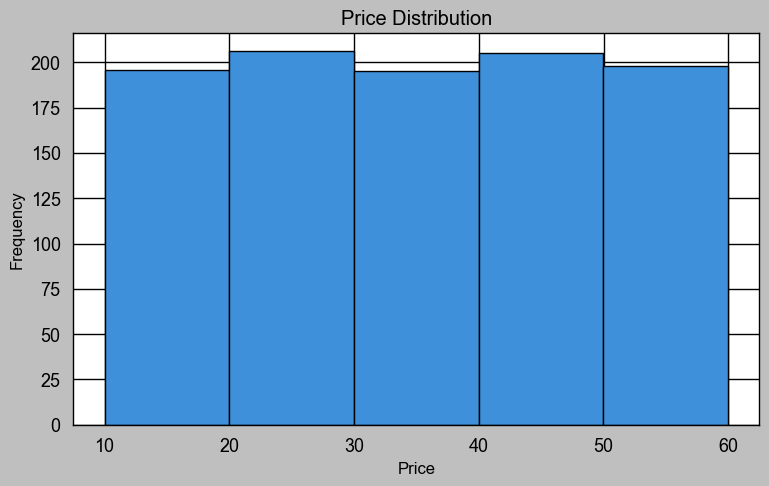

In [139]:
plt.style.use('petroff10')
df['Price'].plot(kind='hist', title='Price Distribution', bins = 5, xlabel='Price', edgecolor='black', linewidth=1.0, figsize=(7,4))

<Axes: title={'center': 'Rating Distribution'}, xlabel='Rating', ylabel='Frequency'>

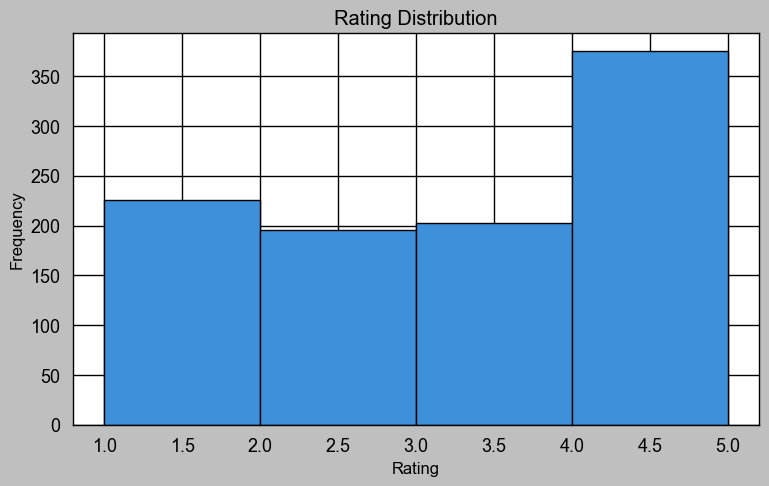

In [141]:
df['Rating'].plot(kind='hist', bins= 4, title='Rating Distribution', xlabel='Rating', linewidth=1.0,edgecolor='black',figsize=(7,4))

In [ ]:
pd.set_option('display.max_rows', None)

In [ ]:
#books per genre
df['Genre'].value_counts()

Genre
Default               152
Nonfiction            110
Sequential Art         75
Add a comment          67
Fiction                65
Young Adult            54
Fantasy                48
Romance                35
Mystery                32
Food and Drink         30
Childrens              29
Historical Fiction     26
Poetry                 19
Classics               19
History                18
Horror                 17
Womens Fiction         17
Science Fiction        16
Science                14
Music                  13
Business               12
Travel                 11
Thriller               11
Philosophy             11
Humor                  10
Autobiography           9
Art                     8
Religion                7
Psychology              7
Spirituality            6
New Adult               6
Christian Fiction       6
Self Help               5
Biography               5
Sports and Games        5
Health                  4
Politics                3
Contemporary            3
Christ

In [ ]:
pd.reset_option('display.max_rows')

In [ ]:
#Average price,rating,stock per genre
df.groupby('Genre').agg({'Price' : 'mean', 'Rating' : 'mean' , 'Stock' : 'mean'}).sort_values('Rating', ascending =False).round(2)

,Price,Rating,Stock
Genre,,,
Erotica,19.19,5.00,15.00
Adult Fiction,15.36,5.00,3.00
Novels,54.81,5.00,9.00
Christian Fiction,34.38,4.17,9.17
Health,51.45,3.75,12.25
Art,38.52,3.62,9.00
Poetry,35.97,3.53,12.37
Humor,33.50,3.40,8.40
Spirituality,35.10,3.33,11.50


<Axes: xlabel='Genre', ylabel='Avg Rating'>

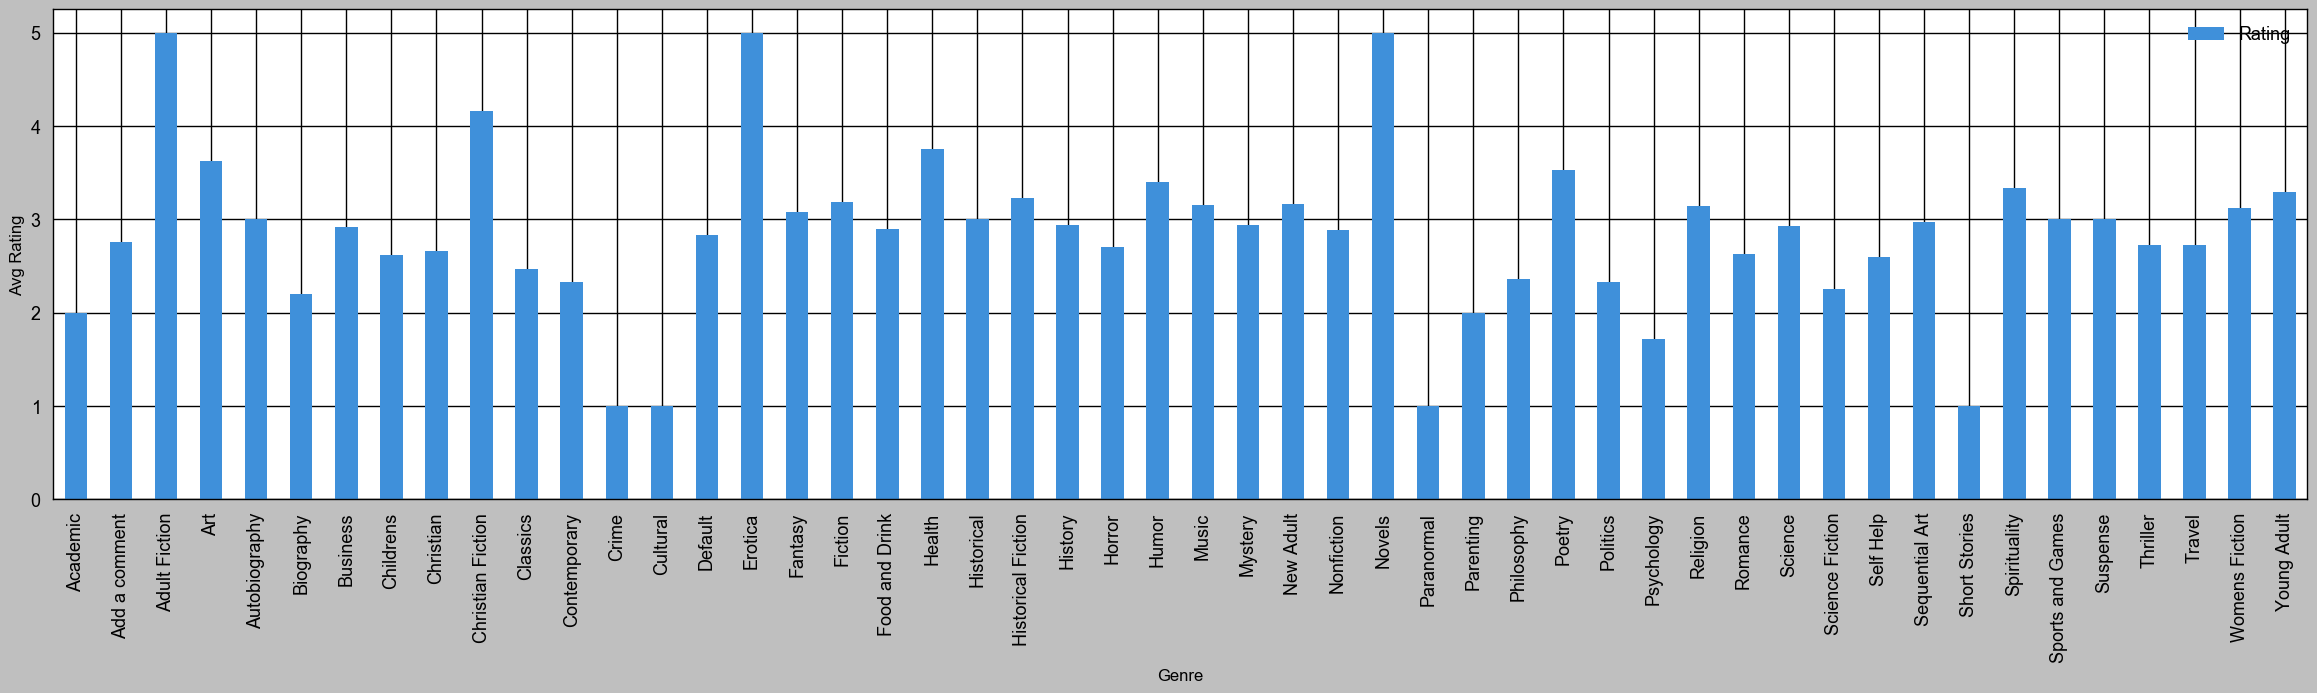

In [113]:
#Average Rating per Genre
df.groupby('Genre').agg({'Rating' : 'mean'}).plot(kind='bar', ylabel='Avg Rating',figsize=(23,5))

<Axes: xlabel='Price', ylabel='Rating'>

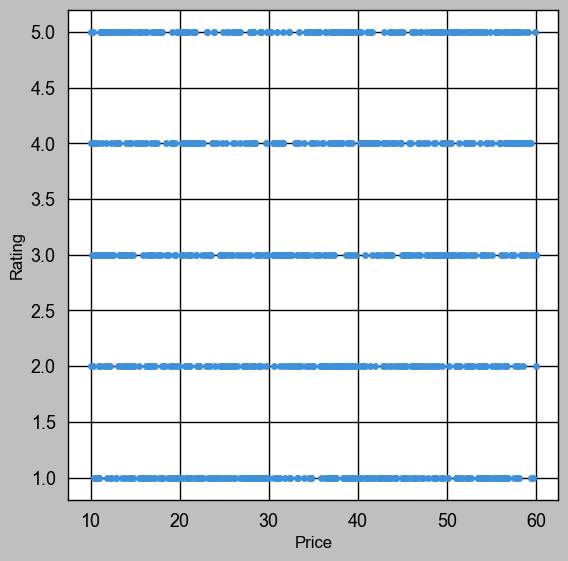

In [ ]:
#Price vs Rating
df.plot(kind='scatter', x='Price', y='Rating', figsize=(5,5))
#There is no correlation between rating and price

In [ ]:
df['Price'].corr(df['Rating'])

np.float64(0.028166239485872963)

In [122]:
df[['Price','Stock','Rating']].corr()

,Price,Stock,Rating
Price,1.000000,-0.010914,0.028166
Stock,-0.010914,1.000000,0.016166
Rating,0.028166,0.016166,1.000000


In [ ]:
#zero outliers
Q1 = df['Price'].quantile(0.25)
Q3 = df['Price'].quantile(0.75)
IQR = Q3 - Q1

outliers = df[(df['Price'] < Q1 - 1.5*IQR) |
              (df['Price'] > Q3 + 1.5*IQR)]

outliers

,Title,Genre,Price,Rating,Stock


<Axes: >

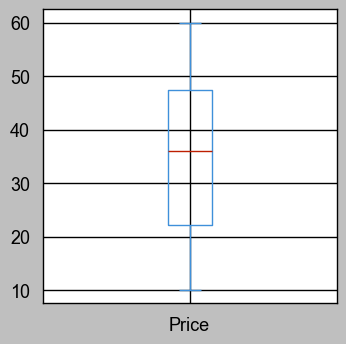

In [127]:
df['Price'].plot(kind='box', figsize=(3,3))

In [ ]:
#Top 10 Best Value Books
df['Value_Score'] = df['Rating'] / df['Price']
df.sort_values('Value_Score').tail(10)

,Title,Genre,Price,Rating,Stock,Value_Score
535,Every Heart a Doorway (Every Heart A Doorway #1),Fantasy,12.16,5,7,0.411184
261,Superman Vol. 1: Before Truth (Superman by Gen...,Sequential Art,11.89,5,14,0.420521
277,Old School (Diary of a Wimpy Kid #10),Humor,11.83,5,14,0.422654
900,"Fruits Basket, Vol. 2 (Fruits Basket #2)",Sequential Art,11.64,5,2,0.429553
521,"Naturally Lean: 125 Nourishing Gluten-Free, Pl...",Food and Drink,11.38,5,7,0.439367
601,The Darkest Corners,Young Adult,11.33,5,5,0.441306
316,Dear Mr. Knightley,Fiction,11.21,5,14,0.446030
590,The Power Greens Cookbook: 140 Delicious Super...,Food and Drink,11.05,5,5,0.452489
302,Greek Mythic History,Default,10.23,5,14,0.488759
638,An Abundance of Katherines,Young Adult,10.00,5,5,0.500000
